# Prithvi WxC Downscaling with CORDEX Data: Model Fine-tuning

This notebook demonstrates how to fine-tune the `Prithvi` downscaling model on CORDEX SA data.

We show how to set up the model, load the pretrained weights, and run finetuning using the CORDEX-derived inputs.

The datasets are from https://zenodo.org/records/17517423

---

## Setup

Python >= 3.10 is required

Make sure that your current working directory is `granite-wxc/`

In [1]:
import os
from pathlib import Path
REPO_ROOT = Path("/mnt/data2/kyo/granite-wxc").resolve()
os.chdir("/mnt/data2/kyo/granite-wxc/examples/CORDEX_ML")
print(f"Working directory set to: {Path.cwd()}")

Working directory set to: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML


In [2]:
# Select idle GPUs before any CUDA initialization
import os
import subprocess

MIN_FREE_GB = 20  # adjust if needed
MAX_GPUS = None  # set to an int to cap GPU count

def _select_idle_gpus(min_free_gb=8, max_gpus=None):
    if os.environ.get('CUDA_VISIBLE_DEVICES'):
        visible = os.environ['CUDA_VISIBLE_DEVICES'].split(',')
        return [int(v) for v in visible if v.strip() != '']
    try:
        out = subprocess.check_output(
            [
                'nvidia-smi',
                '--query-gpu=index,memory.free',
                '--format=csv,noheader,nounits',
            ],
            text=True,
        )
    except Exception as exc:
        print(f'GPU auto-selection skipped (nvidia-smi unavailable): {exc}')
        return None
    rows = []
    for line in out.strip().splitlines():
        if not line.strip():
            continue
        idx_str, free_str = line.split(',')
        idx = int(idx_str.strip())
        free_mb = int(free_str.strip())
        rows.append((idx, free_mb))
    rows.sort(key=lambda x: x[1], reverse=True)
    selected = [idx for idx, free_mb in rows if free_mb >= min_free_gb * 1024]
    if max_gpus is not None:
        selected = selected[:max_gpus]
    return selected

selected_gpus = _select_idle_gpus(MIN_FREE_GB, MAX_GPUS)
if selected_gpus:
    os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
    os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(str(i) for i in selected_gpus)
    NUM_GPUS = len(selected_gpus)
    print(f"Using idle GPUs (CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']})")
else:
    NUM_GPUS = None
    print('Using default CUDA_VISIBLE_DEVICES (no idle GPU filter applied).')


Using idle GPUs (CUDA_VISIBLE_DEVICES=2,3)


In [3]:
# ===================== USER PARAMETERS (EDIT ME) =====================
from sa_params import UserParams, validate_paths


PROJECT_DIR = REPO_ROOT / "examples/CORDEX_ML"
DATASET_ROOT = REPO_ROOT / "granite-geospatial-wxc-downscaling/CORDEX/SA_domain"

TRAIN_SPLIT = "train/Emulator_hist_future"
PREDICTOR_FILE = "ACCESS-CM2_1961-1980_2080-2099_regridded.nc"
TARGET_FILE = "pr_tasmax_ACCESS-CM2_1961-1980_2080-2099.nc"

TRAIN_PREDICTORS = [DATASET_ROOT / TRAIN_SPLIT / "predictors" / PREDICTOR_FILE]
TRAIN_TARGETS = [DATASET_ROOT / TRAIN_SPLIT / "target" / TARGET_FILE]

RUN_NAME_OVERRIDE = 'SA_T2_ACCESS-CM2_static'  # e.g., 'nz_debug_run'
USE_STATIC = True  # set False to ignore static/orography inputs

P = UserParams(
    repo_root=REPO_ROOT,
    project_dir=PROJECT_DIR,
    runs_root=PROJECT_DIR / "runs/SA_T2_ACCESS-CM2_static_train",
    config_path=PROJECT_DIR / "SA_T2_ACCESS-CM2_static.yaml",
    run_name=RUN_NAME_OVERRIDE,
    train_predictor_paths=TRAIN_PREDICTORS,
    train_target_paths=TRAIN_TARGETS,
    val_predictor_paths=TRAIN_PREDICTORS,
    val_target_paths=TRAIN_TARGETS,
    test_predictor_paths=TRAIN_PREDICTORS,
    test_target_paths=TRAIN_TARGETS,
    use_static=USE_STATIC,
    device_target="cuda",
    batch_size=1,
    num_workers=2,
    preferred_checkpoint="best",
)

validate_paths(P)
print(P.summary())


Repo root: /mnt/data2/kyo/granite-wxc
Project dir: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML
Runs root: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/SA_T2_ACCESS-CM2_static_train
Config: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/SA_T2_ACCESS-CM2_static.yaml
Run name override: SA_T2_ACCESS-CM2_static
Inference run override: <latest>
Preferred checkpoint: best
Use static inputs: True
Device target: cuda
Batch size override: 1
Dataloader workers override: 2
Train predictors: 1 file(s)
Validation predictors: 1 file(s)
Test predictors: 1 file(s)
Checkpoint path override: <auto>


If your current directory is not `granite-wxc/`, change it using the following command:

```bash
%cd <local>/granite-wxc/
```

Replace `<local>` with the appropriate path prefix 

In [4]:
!pip install -q git+https://github.com/NASA-IMPACT/Prithvi-WxC.git

In [5]:
import os
import logging
import warnings

logging.disable(logging.CRITICAL)
warnings.simplefilter(action='ignore', category=FutureWarning)

os.chdir(P.project_dir)
print(f"Project directory set to: {os.getcwd()}")

Project directory set to: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML


In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.distributed import DistributedSampler

from cordex_dataset import CordexDownscaleDataset
from cordex_training import (
    get_dataloaders as build_cordex_dataloaders,
    create_finetune_model,
    run_training as launch_cordex_training,
)
from granitewxc.utils.config import get_config
from granitewxc.utils.distributed import init_ddp
from granitewxc.models.model import get_finetune_model_UNET, get_finetune_model
from granitewxc.utils.plot import plot_loss


Pysteps configuration file found at: /mnt/data2/kyo/mamba/envs/Prithvi/lib/python3.10/site-packages/pysteps/pystepsrc



In [7]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

from cordex_dataset import CordexDownscaleDataset
from granitewxc.utils.config import get_config
from granitewxc.utils.distributed import init_ddp
from granitewxc.models.model import get_finetune_model_UNET, get_finetune_model
from granitewxc.utils.plot import plot_loss

Run setup utilities from `examples/CORDEX_ML/run_utils.py` are imported below and rely on the repository path specified in the parameter cell.

In [8]:
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True
torch.manual_seed(123)

It is possible to use a cpu or gpu/s to generate inferences. Based on avaiablity of a `cuda:gpu`, we set the device that the model uses

In [9]:
target = (getattr(P, 'device_target', 'auto') or 'auto').lower()
if target == 'cuda':
    if not torch.cuda.is_available():
        raise RuntimeError("device_target is 'cuda' but no CUDA device is available.")
    device = torch.device('cuda')
    use_gpu = True
elif target == 'cpu':
    device = torch.device('cpu')
    use_gpu = False
else:
    if torch.cuda.is_available():
        device = torch.device('cuda')
        use_gpu = True
    else:
        device = torch.device('cpu')
        use_gpu = False


In [10]:
print(device)

cuda


We initialize the Distributed Data Parallel (DDP) environment to leverage multiple GPUs for training

In [11]:
from pathlib import Path

config_path = P.config_path
config = get_config(str(config_path))
config.device_target = getattr(P, 'device_target', config.device_target)
if getattr(P, "use_static", None) is not None:
    config.data.use_static = bool(P.use_static)

def _override(attr: str, values):
    if values:
        setattr(config.data, attr, [str(Path(p).resolve()) for p in values])

_override('training_predictor_paths', P.train_predictor_paths)
_override('training_target_paths', P.train_target_paths)
_override('validation_predictor_paths', P.val_predictor_paths)
_override('validation_target_paths', P.val_target_paths)
_override('test_predictor_paths', P.test_predictor_paths)
_override('test_target_paths', P.test_target_paths)

if P.batch_size is not None:
    config.batch_size = int(P.batch_size)
if P.num_workers is not None:
    config.dl_num_workers = int(P.num_workers)

train_dl, val_dl = build_cordex_dataloaders(config, use_gpu)
len(train_dl), len(val_dl)


(14600, 14600)

## Configuration File

The model is configured using `YAML` files.

In these files, you specify:
- Paths to the input data  
- Locations of the pretrained weights  

To ensure compatibility with the provided weights during inference, keep the model configuration consistent with the original definitions 

In [12]:
import os

os.chdir(P.repo_root)
!pip install -e .
os.chdir(P.project_dir)

Obtaining file:///mnt/data2/kyo/granite-wxc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for granitewxc (pyproject.toml) ... done
  Created wheel for granitewxc: filename=granitewxc-0.1.1rc1-0.editable-py3-none-any.whl size=7229 sha256=eea1067b1cf226fd32fabb9db7d5cd4a02ba63f784a4ef0ffd1ba5493a29a30f
  Stored in directory: /tmp/pip-ephem-wheel-cache-_ouo0x4a/wheels/2e/5a/11/41fce76ea3198050a52e231f82b3b2c64b4f69dcb246e0a2b6
Successfully built granitewxc
  Attempting uninstall: granitewxc
    Found existing installation: granitewxc 0.1.1rc1
    Uninstalling granitewxc-0.1.1rc1:
      Successfully uninstalled granitewxc-0.1.1rc1


In [13]:
# Configuration already loaded using the USER PARAMETERS block.

In [14]:
# Working directory managed via the parameter cell.

In [15]:
from datetime import datetime
from pathlib import Path

from run_utils import (
    copy_scalars_to_run,
    prepare_run_paths,
    snapshot_resolved_config,
    update_manifest,
    write_manifest,
)
from sa_params import resolve_run_dir, export_params

RUN_NAME, resolved_run_dir = resolve_run_dir(P, config)
run_paths = prepare_run_paths(Path(P.runs_root), RUN_NAME)
assert run_paths.run_dir == resolved_run_dir

config.path_experiment = str(run_paths.run_dir)
config.checkpoint_dir = str(run_paths.checkpoints)
config.scalar_dir = str(run_paths.scalars)
config.preproc_dir = str(run_paths.preproc)

scalar_records = copy_scalars_to_run(config, run_paths.scalars)
resolved_config_path = snapshot_resolved_config(
    config, run_paths.config_dir / "resolved.yaml"
)
manifest = write_manifest(
    run_paths,
    run_name=RUN_NAME,
    base_config=str(config_path),
    resolved_config=resolved_config_path,
    scalars=scalar_records,
)

params_json = export_params(P, run_paths.run_dir / "params.json", extra={"run_name": RUN_NAME})
print(f"Run artifacts will be stored in {run_paths.run_dir}")
print(f"Config snapshot: {resolved_config_path}")
print(f"Saved parameter snapshot to {params_json}")

Run artifacts will be stored in /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/SA_T2_ACCESS-CM2_static_train/SA_T2_ACCESS-CM2_static
Config snapshot: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/SA_T2_ACCESS-CM2_static_train/SA_T2_ACCESS-CM2_static/config/resolved.yaml
Saved parameter snapshot to /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/SA_T2_ACCESS-CM2_static_train/SA_T2_ACCESS-CM2_static/params.json


## Dataloader 

In this CORDEX example we will use a single regridded data pair for both training and validation.

In [16]:
# This cell is deprecated; please use the helper functions defined earlier for dataloaders.


### Sample shapes

We check the batched tensor shapes from the CORDEX dataloader.

In [17]:
example_batch = next(iter(train_dl))
if "static_x" in example_batch:
    example_batch["x"].shape, example_batch["y"].shape, example_batch["static_x"].shape
else:
    example_batch["x"].shape, example_batch["y"].shape


In [18]:
target_shape = tuple(example_batch["y"].shape)
var_names = list(config.data.output_vars)
print(f"Configured output variables: {var_names}")
print(f"Sample target tensor shape: {target_shape}")
if target_shape[1] != len(var_names):
    raise ValueError(
        f"Dataloader returned {target_shape[1]} channels but config specifies {len(var_names)}"
    )
missing_expected = {"pr", "tasmax"} - set(var_names)
if missing_expected:
    raise ValueError(f"Missing expected SA targets: {sorted(missing_expected)}")
print("Fine-tuning includes both 'pr' and 'tasmax'.")


Configured output variables: ['pr', 'tasmax']
Sample target tensor shape: (1, 2, 128, 128)
Fine-tuning includes both 'pr' and 'tasmax'.


## Model Initialization

We provide **2** different model architectures `UNET-like` and `CONV` 

Both architectures include:  
1. **Patch Embedding**: Extracts shallow features from the input data  
2. **Feature Extraction**: Utilizes the Prithvi backbone to extract deeper features  

The key difference is that the UNET-like version incorporates **static high-resolution data** into the model

In this notebook, we use the **UNET-like** version

To switch to the **CONV** model, update the configuration file accordingly and use `get_finetune_model(config)` 

In [19]:
model = create_finetune_model(config).to(device)


Creating the model.
--> model has 254,372,744 params.
Loaded 200 tensors from /mnt/data2/kyo/granite-wxc/granite-geospatial-wxc-downscaling/ECCC/weights/best_rmse_UNET_small.pt. Skipped 8 mismatched entries.


We can now load the pretrained weights

In [20]:
# Pretrained weights are loaded via create_finetune_model().


## Finetuning

The model is now ready for training

In [21]:
from torch.optim import AdamW
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

from granitewxc.utils.trainer import train_model
from granitewxc.models.loss import rmse_loss

## 
Defining the optimizer, scaler, and scheduler for the training process.

In [22]:
# Optimizer configuration handled inside cordex_training.run_training.


We'll train the model using just 1 data pair and run it for only 5 epochs

Let's train it for a couple of epochs based on the configuration file

In [23]:
try:
    train_losses, val_losses = launch_cordex_training(config, num_gpus=(NUM_GPUS or torch.cuda.device_count()), save_every=5)
except Exception as exc:
    print(f"Training failed: {exc}")
    raise


Creating the model.
--> model has 254,372,744 params.
Loaded 200 tensors from /mnt/data2/kyo/granite-wxc/granite-geospatial-wxc-downscaling/ECCC/weights/best_rmse_UNET_small.pt. Skipped 8 mismatched entries.


/mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/cordex_training.py:305: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_gpu and torch.cuda.is_available())
[rank0]:[W126 22:35:18.404382267 ProcessGroupNCCL.cpp:4115] [PG ID 0 PG GUID 0 Rank 0]  using GPU 0 to perform barrier as devices used by this process are currently unknown. This can potentially cause a hang if this rank to GPU mapping is incorrect.Specify device_ids in barrier() to force use of a particular device,or call init_process_group() with a device_id.
/mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/cordex_training.py:305: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_gpu and torch.cuda.is_available())
[rank1]:[W126 22:35:18.457000207 ProcessGroupNCCL.cpp:4115] [PG ID 0 PG GUID 0 Rank 1]  using GPU 1 to p

Learning rate: 5e-05
Rank 0 starting epoch 1...
Learning rate: 5e-05
Rank 1 starting epoch 1...


Training Epoch 1/5:   0%|          | 0/200 [00:00<?, ?batch/s]/home/kyo/.local/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/kyo/.local/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return 

Distributed training failed with signal/exit (process 0 terminated with signal SIGABRT); retrying on a single GPU.
Creating the model.
--> model has 254,372,744 params.
Loaded 200 tensors from /mnt/data2/kyo/granite-wxc/granite-geospatial-wxc-downscaling/ECCC/weights/best_rmse_UNET_small.pt. Skipped 8 mismatched entries.
Learning rate: 5e-05
Rank 0 starting epoch 1...


...

Validation Epoch: 100%|██████████| 50/50 [00:28<00:00,  1.73batch/s, loss=5.91]


--> saved /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/SA_T2_ACCESS-CM2_static_train/SA_T2_ACCESS-CM2_static/checkpoints/best.ckpt
Learning rate: 5.679083637813779e-06
Rank 0 starting epoch 5...


Training Epoch 5/5: 100%|██████████| 200/200 [05:26<00:00,  1.63s/batch, loss=5.21, lr=1e-6]   


Validation Epoch: 100%|██████████| 50/50 [00:28<00:00,  1.73batch/s, loss=4.61]


--> saved /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/SA_T2_ACCESS-CM2_static_train/SA_T2_ACCESS-CM2_static/checkpoints/best.ckpt


In [24]:
from pathlib import Path

checkpoint_info = {
    "best": str(Path(config.checkpoint_dir) / "best.ckpt"),
    "last": str(Path(config.checkpoint_dir) / "last.ckpt"),
}
manifest = update_manifest(run_paths.run_dir, checkpoints=checkpoint_info)
print("Updated run manifest with checkpoint locations:")
for label, ckpt_path in checkpoint_info.items():
    print(f"  {label}: {ckpt_path}")


Updated run manifest with checkpoint locations:
  best: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/SA_T2_ACCESS-CM2_static_train/SA_T2_ACCESS-CM2_static/checkpoints/best.ckpt
  last: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/SA_T2_ACCESS-CM2_static_train/SA_T2_ACCESS-CM2_static/checkpoints/last.ckpt


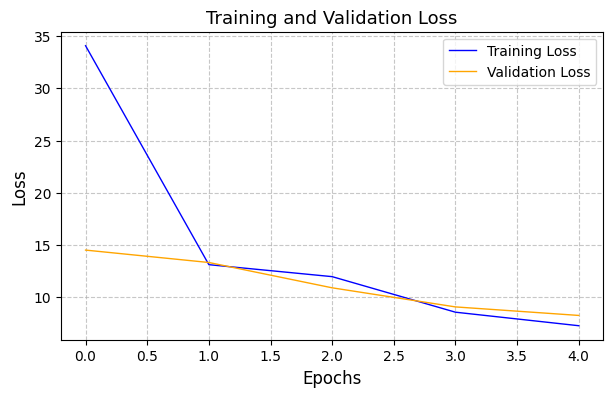

In [25]:
plot_loss(train_losses, val_losses)